In [1]:
import pandas as pd, numpy as np, os
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',False)
pd.set_option('display.max_rows',False)


In [2]:
# pip install openpyxl, pandas , numpy, matplotlib

In [3]:
df = pd.read_excel('External_Cibil_Dataset.xlsx',);df.shape

(51336, 62)

In [4]:
#design bad rates max_deliq_12mts <-- use this!

print([x for x in df.columns if 'max' in x])
print(df['max_deliq_12mts'].value_counts(dropna=False)/df.shape[0]*100)
df['bad_flag_90_12'] = df['max_deliq_12mts'].copy()

df['bad_flag_90_12'] = np.where(df['bad_flag_90_12']==-99999,0,df['bad_flag_90_12'])
df['bad_flag_90_12'] = np.where(df['bad_flag_90_12']==0,0,1)

print(df["bad_flag_90_12"].value_counts(dropna=False)/df.shape[0]*100)
print(62.482468+21.100203)

['max_delinquency_level', 'max_recent_level_of_deliq', 'max_deliq_6mts', 'max_deliq_12mts', 'max_unsec_exposure_inPct']
max_deliq_12mts
 0        62.482468
-99999    21.100203
 28        1.098644
 26        0.979819
 27        0.853202
 25        0.833723
 3         0.736325
 30        0.724638
 24        0.617500
 29        0.562958
 10        0.504519
 1         0.379850
 11        0.366215
 89        0.364267
 56        0.298036
            ...    
 268       0.001948
 575       0.001948
 438       0.001948
 231       0.001948
 109       0.001948
 372       0.001948
 134       0.001948
 650       0.001948
 647       0.001948
 381       0.001948
 102       0.001948
 281       0.001948
 337       0.001948
 363       0.001948
 95        0.001948
Name: count, Length: 294, dtype: float64
bad_flag_90_12
0    83.582671
1    16.417329
Name: count, dtype: float64
83.582671


In [5]:
#### START ####
### IV ###

bin_edges={} #to save bin edges!
def calculate_IV(colname, X, y, n_bins, num_bin_unique_to_bin):
    #n_bins mustn't exceed num_unique_bins
    nrows = X.shape[0]
    if y is None:
        y = np.full((nrows, ), 0, dtype=int)
    data = pd.DataFrame({colname: X[colname],'y':y})
    data.replace(np.inf, np.nan, inplace=True)
    
    data['goods'] = np.where(data['y']!=1,1,0)
    data['bads'] = np.where(data['y'] ==1,1,0)

    data_miss = data[data[colname].isnull()]
    data = data[~(data[colname].isnull())]

    if np.issubdtype(data[colname].dtype, np.number)==True:
        uniq = data[colname].unique()
        uniq.sort()
        uniqlen = len(uniq)
        if (uniqlen <= num_bin_unique_to_bin):
            ncuts = [-float('inf')] + uniq.tolist()+ [float('inf')]
        else:
            _, ncuts = pd.qcut(data[colname], q=n_bins, retbins=True, duplicates='drop')
            ncuts[0]= -float('inf')
            ncuts[-1] = float("inf")
        data[colname] = pd.cut(data[colname],bins=ncuts)
    else:
        data[colname] = data[colname]
    
    bin_edges[colname] = list(ncuts)

    import json
    with open('bin_edges_final.json','w') as f:
        json.dump({'bin_edges':bin_edges},f)
    print('Bin_Rules_Saved for {}!!!'.format(colname))
    
    #######################################################################################
    print("IV_CALC_START!!!")
    data_good = data.groupby(by=[colname])['goods'].sum().reset_index()
    data_bad = data.groupby(by=[colname])['bads'].sum().reset_index()
    data_info = data_good.merge(data_bad,on= colname,how='left')
    data_info['total'] = data_info['goods'] + data_info['bads']
    data_info['bin_number'] = data_info.index +1

    data_miss_group = pd.DataFrame({'goods':np.sum(data_miss['goods']),
                                   'bads':np.sum(data_miss['bads']),
                                   'bin':'missing'},index=[0])
    data_miss_group['total'] = data_miss_group['goods'] + data_miss_group['bads'] 
    data_miss_group['bin_number'] = 0
    
    data_info = pd.concat([data_info,data_miss_group],ignore_index=True,sort = True)
    data_info = data_info.loc[:,['bin_number','bin','goods','bads','total']]
    data_info = data_info.sort_values(by=['bin_number'])

    #woe
    data_info['group_goods_percentage'] = data_info['goods']/data_info['goods'].sum()
    data_info['group_bads_percentage'] = data_info['bads']/data_info['bads'].sum()
    data_info['group_total_percentage'] = data_info['total']/data_info['total'].sum()
    
    data_info['rate'] = np.round((data_info['bads']/data_info['bads'].sum()),4)
    data_info['woe'] = np.log((data_info['group_goods_percentage']/data_info['group_bads_percentage']))
    data_info['iv'] = (data_info['group_goods_percentage'] - data_info['group_bads_percentage'])*data_info['woe']
    data_info['variable'] = colname
    data_info.replace(np.nan,0,inplace=True)
    data_info.replace(np.inf,0,inplace=True)
    #result = [colname, data_info]
    rez = data_info['iv'].sum()
    rezz= data_info # comment this if not req: to get woe that is!!
    
    return bin_edges, rez , rezz
    

In [6]:
bin_edges,iv_final, ivd = calculate_IV("tot_enq",df,df['bad_flag_90_12'],5,10)
ivd # <== woe table : tot_enq total IV => 0.261741

Bin_Rules_Saved for tot_enq!!!
IV_CALC_START!!!


,bin_number,bin,goods,bads,total,group_goods_percentage,group_bads_percentage,group_total_percentage,rate,woe,iv,variable
5,0,missing,0,0,0,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,tot_enq
0,1,0,14469,1328,15797,0.337210,0.157570,0.307718,0.1576,0.760836,0.136676,tot_enq
1,2,0,6788,1014,7802,0.158199,0.120313,0.151979,0.1203,0.273755,0.010371,tot_enq
2,3,0,8808,1905,10713,0.205276,0.226032,0.208684,0.2260,-0.096320,0.001999,tot_enq
3,4,0,6267,1661,7928,0.146057,0.197081,0.154434,0.1971,-0.299621,0.015288,tot_enq
4,5,0,6576,2520,9096,0.153258,0.299003,0.177186,0.2990,-0.668331,0.097406,tot_enq


In [49]:
# df['tot_enq_bin_ani'] = pd.qcut(df['tot_enq'],q=5,duplicates='drop')
# df['tot_enq_bin_ani'] = df['tot_enq_bin_ani'].astype(str)
# df['tot_enq_bin_ani'].value_counts()
# #df['tot_enq_bin_ani'].value_counts()/df.shape[0]*100

In [48]:
# ## ALTERNATE ###

# var = "tot_enq_bin_ani"
# target = "bad_flag_90_12"

# woe_iv = (pd.crosstab(df[var],df[target],normalize='columns').assign(woe = lambda dfi:np.log(dfi[1]/dfi[0]))
#                                                     .assign(iv = lambda dfi:np.sum(dfi["woe"]*(dfi[1]-dfi[0]))))
# print(woe_iv)
# woe_iv.reset_index(inplace=True)
# # your answer: 0.26174 and 

In [50]:
###### MINE ANIRUDH ########
#pct_of_active_TLs_ever
df['pct_of_active_TLs_ever_ani'] = pd.qcut(df['pct_of_active_TLs_ever'],q=5,duplicates='drop')
df['pct_of_active_TLs_ever_ani'] = df['pct_of_active_TLs_ever_ani'].astype(str)
print(df['pct_of_active_TLs_ever_ani'].value_counts())



dff = df.groupby('pct_of_active_TLs_ever_ani').agg(bads= pd.NamedAgg('bad_flag_90_12','sum'),
                                       pop = pd.NamedAgg('bad_flag_90_12','count')).reset_index()
dff['goods'] = dff['pop'] - dff['bads']
dff['%goods'] = dff['goods']/dff['goods'].sum()
dff['%bads'] = dff['bads']/dff['bads'].sum()
dff['%pop'] = dff['pop']/dff['pop'].sum()

######### 
dff['woe'] = np.log(dff['%goods']/dff['%bads'])
dff['iv'] = dff['woe']*(dff['%goods']-dff['%bads'])
dff['iv_final'] = dff['iv'].sum()


### my answer: 0.144966 , ref: pct_of_active_TLs_ever	0.144966
dff.head(10)

pct_of_active_TLs_ever_ani
(0.75, 1.0]        19799
(0.167, 0.5]       14587
(-0.001, 0.167]    10687
(0.5, 0.75]         6263
Name: count, dtype: int64


,pct_of_active_TLs_ever_ani,bads,pop,goods,%goods,%bads,%pop,woe,iv,iv_final
0,"(-0.001, 0.167]",1045,10687,9642,0.224713,0.123991,0.208177,0.594613,0.059891,0.144966
1,"(0.167, 0.5]",3106,14587,11481,0.267572,0.368533,0.284148,-0.320141,0.032322,0.144966
2,"(0.5, 0.75]",1546,6263,4717,0.109933,0.183436,0.122000,-0.511997,0.037633,0.144966
3,"(0.75, 1.0]",2731,19799,17068,0.397781,0.324039,0.385675,0.205039,0.015120,0.144966


In [40]:
dff['tot_enq_bin_ani'].value_counts()

tot_enq_bin_ani
(-99999.001, 1.0]    1
(1.0, 2.0]           1
(2.0, 4.0]           1
(4.0, 7.0]           1
(7.0, 176.0]         1
Name: count, dtype: int64

In [6]:
dsn = df.copy()

req = ['time_since_recent_payment',
'time_since_first_deliquency', 'time_since_recent_deliquency',
'num_times_delinquent', 'max_delinquency_level',
'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts',
'num_deliq_6_12mts', 'max_deliq_6mts', 'max_deliq_12mts',
'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts',
'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt',
'num_dbt_6mts', 'num_dbt_12mts', 'num_lss', 'num_lss_6mts',
'num_lss_12mts', 'recent_level_of_deliq', 'tot_enq', 'CC_enq',
'CC_enq_L6m', 'CC_enq_L12m', 'PL_enq', 'PL_enq_L6m', 'PL_enq_L12m',
'time_since_recent_enq', 'enq_L12m', 'enq_L6m', 'enq_L3m','NETMONTHLYINCOME',
'Time_With_Curr_Empr', 'pct_of_active_TLs_ever',
'pct_opened_TLs_L6m_of_L12m', 'pct_currentBal_all_TL', 'CC_utilization',
'CC_Flag', 'PL_utilization', 'PL_Flag', 'pct_PL_enq_L6m_of_L12m',
'pct_CC_enq_L6m_of_L12m', 'pct_PL_enq_L6m_of_ever',
'pct_CC_enq_L6m_of_ever', 'max_unsec_exposure_inPct', 'HL_Flag',
'GL_Flag']

main_df = []
for col in req:
    bin_edges,iv_final = calculate_IV(col,dsn,dsn['bad_flag_90_12'],5,10)
    print(iv_final,bin_edges)
    print("######################################################################")
    rez2 = col,iv_final
    main_df.append(rez2)
print('!!! completed  !!!')

print('columns not considered:', df.columns.difference(req) )

Bin_Rules_Saved for time_since_recent_payment!!!
IV_CALC_START!!!
0.16072621843343 {'time_since_recent_payment': [np.float64(-inf), np.float64(41.0), np.float64(60.0), np.float64(82.0), np.float64(258.0), np.float64(inf)]}
######################################################################
Bin_Rules_Saved for time_since_first_deliquency!!!
IV_CALC_START!!!
0.36574515666734864 {'time_since_recent_payment': [np.float64(-inf), np.float64(41.0), np.float64(60.0), np.float64(82.0), np.float64(258.0), np.float64(inf)], 'time_since_first_deliquency': [np.float64(-inf), np.float64(13.0), np.float64(inf)]}
######################################################################
Bin_Rules_Saved for time_since_recent_deliquency!!!
IV_CALC_START!!!
0.17162728903590457 {'time_since_recent_payment': [np.float64(-inf), np.float64(41.0), np.float64(60.0), np.float64(82.0), np.float64(258.0), np.float64(inf)], 'time_since_first_deliquency': [np.float64(-inf), np.float64(13.0), np.float64(inf)], 'time_

In [7]:
IV_df = pd.DataFrame(main_df,columns=['variable','IV'])
IV_df = IV_df.sort_values(by=['IV'],ascending=False).head(30);IV_df

,variable,IV
5,max_recent_level_of_deliq,1.490007
25,recent_level_of_deliq,1.394905
3,num_times_delinquent,1.381629
4,max_delinquency_level,1.361655
9,max_deliq_6mts,0.475436
1,time_since_first_deliquency,0.365745
26,tot_enq,0.261741
2,time_since_recent_deliquency,0.171627
0,time_since_recent_payment,0.160726
39,pct_of_active_TLs_ever,0.144966


In [8]:
#### AUTO BINNER ####
import json
print(os.getcwd())

file_path = 'bin_edges_final.json'

def load_bin_edges(file_path):
    with open(file_path,'r') as f:
        bin_edges = json.load(f)
        for col in bin_edges['bin_edges']:
            bin_edges['bin_edges'][col] = np.array(bin_edges['bin_edges'][col])
        return bin_edges['bin_edges']

def apply_bin_edges(df,bin_edges):
    for col in df.columns:
        if col in bin_edges:
            df[col+ '_bin'] = pd.cut(df[col],bins=bin_edges[col],include_lowest=True)
    return df

### FINAL DF DESIGN ###
bin_edges = load_bin_edges(file_path)
dfx = apply_bin_edges(df,bin_edges)
dfx['id'] = df['PROSPECTID'].copy()
dfx['bad_flag_90_12'] = df['bad_flag_90_12'].copy()# subject to change accordingly!!!

rew = [x for x in dfx.columns if '_bin' in x]
w = ['id','bad_flag_90_12']
rew= rew+w
dfx[rew].columns

D:\2026_s_tasks\works_2026


Index(['time_since_recent_payment_bin', 'time_since_first_deliquency_bin',
       'time_since_recent_deliquency_bin', 'num_times_delinquent_bin',
       'max_delinquency_level_bin', 'max_recent_level_of_deliq_bin',
       'num_deliq_6mts_bin', 'num_deliq_12mts_bin', 'num_deliq_6_12mts_bin',
       'max_deliq_6mts_bin', 'max_deliq_12mts_bin', 'num_times_30p_dpd_bin',
       'num_times_60p_dpd_bin', 'num_std_bin', 'num_std_6mts_bin',
       'num_std_12mts_bin', 'num_sub_bin', 'num_sub_6mts_bin',
       'num_sub_12mts_bin', 'num_dbt_bin', 'num_dbt_6mts_bin',
       'num_dbt_12mts_bin', 'num_lss_bin', 'num_lss_6mts_bin',
       'num_lss_12mts_bin', 'recent_level_of_deliq_bin', 'tot_enq_bin',
       'CC_enq_bin', 'CC_enq_L6m_bin', 'CC_enq_L12m_bin', 'PL_enq_bin',
       'PL_enq_L6m_bin', 'PL_enq_L12m_bin', 'time_since_recent_enq_bin',
       'enq_L12m_bin', 'enq_L6m_bin', 'enq_L3m_bin', 'NETMONTHLYINCOME_bin',
       'Time_With_Curr_Empr_bin', 'pct_of_active_TLs_ever_bin',
       'pct_opene

Axes(0.125,0.11;0.775x0.77)
done!


,enq_L12m_bin,bads,pop,bad_rate
0,"(-inf, 0.0]",1713,15694,10.914999
1,"(0.0, 1.0]",1600,11200,14.285714
2,"(1.0, 2.0]",1347,7284,18.492586
3,"(2.0, 4.0]",1764,8229,21.436384
4,"(4.0, inf]",2004,8929,22.443723


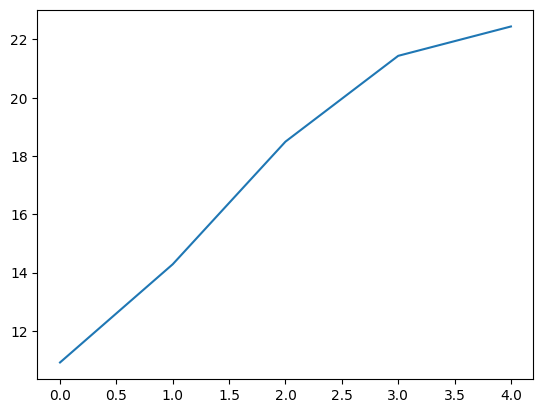

In [9]:
#lets test it out!

x1 = dfx.groupby(['enq_L12m_bin']).agg(bads = pd.NamedAgg(
    'bad_flag_90_12','sum'),pop = pd.NamedAgg('id','count')).reset_index()
x1['bad_rate'] = x1['bads']/x1['pop']*100
print(x1.bad_rate.plot())
print('done!')
x1

In [10]:
### THIS WORKS WELL ###

In [11]:
### VIF ###

In [12]:
req2 = list(IV_df["variable"].head(25))
idd = ['bad_flag_90_12']
req2 = req2+idd

dfxn = dfx[req2]
dfxn.columns

Index(['max_recent_level_of_deliq', 'recent_level_of_deliq',
       'num_times_delinquent', 'max_delinquency_level', 'max_deliq_6mts',
       'time_since_first_deliquency', 'tot_enq',
       'time_since_recent_deliquency', 'time_since_recent_payment',
       'pct_of_active_TLs_ever', 'enq_L12m', 'max_unsec_exposure_inPct',
       'pct_currentBal_all_TL', 'enq_L3m', 'enq_L6m', 'GL_Flag', 'CC_Flag',
       'CC_enq', 'PL_enq', 'time_since_recent_enq', 'PL_Flag',
       'pct_opened_TLs_L6m_of_L12m', 'CC_enq_L12m', 'NETMONTHLYINCOME',
       'PL_enq_L12m', 'bad_flag_90_12'],
      dtype='object')

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = dfxn.drop('bad_flag_90_12', axis=1)
X = add_constant(X)

vif_data = pd.DataFrame()
vif_data['variables'] = X.columns
vif_data['vif'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data['vif'] = round(vif_data['vif'],4)
vif_data['vif'] = vif_data['vif'].astype(str)
vif_data

## VIF READY ##

,variables,vif
0,const,17.577
1,max_recent_level_of_deliq,7.1635
2,recent_level_of_deliq,4.7155
3,num_times_delinquent,3.4088
4,max_delinquency_level,1699554.5525
5,max_deliq_6mts,1.4489
6,time_since_first_deliquency,161036343.3795
7,tot_enq,256134858.7663
8,time_since_recent_deliquency,161705389.0426
9,time_since_recent_payment,1.114


In [14]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.tools.tools import add_constant

# X = dfxn.drop('bad_flag_90_12', axis=1)
# X = add_constant(X)
# viff = pd.DataFrame([variance_inflation_factor(X.values, i) 
#                for i in range(X.shape[1])], 
#               index=X.columns,columns=['vif'])

# viff.reset_index(inplace=True)
# viff['vif'] = round(viff['vif'],4)
# viff.head(3)
######################################

# m = []
# for var_nos in range(X.shape[1]):
#     col = X.columns[var_nos] 
#     res = variance_inflation_factor(X.values,var_nos)
#     res2 = res,col
#     m.append(res2)
# m

In [23]:
dfxn.head(3)
#bad_flag_90_12



,max_recent_level_of_deliq,recent_level_of_deliq,num_times_delinquent,max_delinquency_level,max_deliq_6mts,time_since_first_deliquency,tot_enq,time_since_recent_deliquency,time_since_recent_payment,pct_of_active_TLs_ever,enq_L12m,max_unsec_exposure_inPct,pct_currentBal_all_TL,enq_L3m,enq_L6m,GL_Flag,CC_Flag,CC_enq,PL_enq,time_since_recent_enq,PL_Flag,pct_opened_TLs_L6m_of_L12m,CC_enq_L12m,NETMONTHLYINCOME,PL_enq_L12m,bad_flag_90_12,time_since_recent_payment_bin,max_deliq_6mts_bin,NETMONTHLYINCOME_bin
0,29,29,11,29,-99999,35,6,15,549,0.2,0,13.333,0.798,0,0,0,0,0,6,566,1,0.0,0,51000,0,0,"(258.0, 6065.0]","(-99999.001, 0.0]","(35000.0, 2500000.0]"
1,0,0,0,-99999,0,-99999,1,-99999,47,1.0,1,0.860,0.370,0,0,0,0,0,0,209,0,0.0,0,19000,0,0,"(41.0, 60.0]","(-99999.001, 0.0]","(16000.0, 20000.0]"
2,25,25,9,25,25,11,4,3,302,1.0,0,5741.667,0.585,0,0,0,0,0,0,587,0,0.5,0,18,0,1,"(258.0, 6065.0]","(0.0, 900.0]","(-0.001, 16000.0]"


In [29]:
#time_since_recent_payment, max_deliq_6mts
dfxn['NETMONTHLYINCOME_bin'] = pd.qcut(dfxn['NETMONTHLYINCOME'],q=5,duplicates='drop')
dfxn['NETMONTHLYINCOME_bin'] = dfxn['NETMONTHLYINCOME_bin'].astype(str)

dfxn['max_deliq_6mts_bin'] = pd.qcut(dfxn['max_deliq_6mts'],q=5,duplicates='drop')
dfxn['max_deliq_6mts_bin'] = dfxn['max_deliq_6mts_bin'].astype(str)

#time_since_recent_payment_bin
pd.pivot_table(dfxn,index='NETMONTHLYINCOME_bin',columns='time_since_recent_payment_bin',values='bad_flag_90_12',
        aggfunc={'bad_flag_90_12':'mean'}).mul(100)

time_since_recent_payment_bin,"(-99999.001, 41.0]","(258.0, 6065.0]","(41.0, 60.0]","(60.0, 82.0]","(82.0, 258.0]"
NETMONTHLYINCOME_bin,,,,,
"(-0.001, 16000.0]",14.254095,6.377760,19.309990,14.025245,18.312937
"(16000.0, 20000.0]",17.952250,6.107206,20.387409,14.187011,17.987533
"(20000.0, 25000.0]",16.598570,7.110666,22.503726,17.579681,18.385890
"(25000.0, 35000.0]",20.626632,8.210024,23.415862,17.890110,18.214771
"(35000.0, 2500000.0]",21.308628,8.788927,22.976643,18.720657,21.675532


In [ ]:
#mob: get the dates in float format: i.e. 20240101

df['reported_dt_2'] = df['reported_dt']//100
df['open_dt_2'] = df['open_dt']//100

df['report_year'] = df['report_dt_2']//100
df['open_year'] = df['open_dt_2']//100

df['report_month'] = df['report_dt_2']%100
df['open_month'] = df['open_dt_2']%100

df['MOB'] = 12*(df['report_year']-report['open_year']) + 
            (df['report_month'] - df['open_month'])

df = df[df['MOB']>0].copy()

### dpd
c1 = (df['balance_amount']>500) # set it as more than 1000 also
c2 = (df['dpd']>720)
## must add written off and settled flags and other plausible 
### conditions such as pay
### ratings!!
main1 = c1 & c2

c3 = ((df['dpd']>360) & (df['dpd']<=720))
main2 = c1 & c3

c4 = ((df['dpd']>180) & (df['dpd']<=360))
main3 = c1 & c4

c5 = ((df['dpd']>90) & (df['dpd']<=180))
main4 = c1 & c5

c6 = ((df['dpd']>60) & (df['dpd']<=90))
main5 = c1 & c6

c7 = ((df['dpd']>30) & (df['dpd']<=60))
main6 = c1 & c7

c8 = ((df['dpd']>0) & (df['dpd']<=30))
main7 = c1 & c8

c9 = ((df['dpd']==0) | (df['dpd'].isna()))
main8 = c1 & c9

df['dpd_values'] = np.where(main1,7,
                   np.where(main2,6,
                   np.where(main3,5,
                   np.where(main4,4,
                   np.where(main5,3,
                   np.where(main6,2,
                   np.where(main7,1,
                   np.where(main8,0,-1))))))))   

In [8]:
### dataframe melt
import pandas as pd, numpy as np, os
pd.set_option('display.max_columns',False)
pd.set_option('display.max_rows',False)

import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv("loan_accounts_outstanding_balances_wide.csv");df.head(3)

,customer_id,loan_account_key,loan_product_number,open_date,sanction_amount,balance_1,balance_2,balance_3,balance_4,balance_5,balance_6,balance_7,balance_8,balance_9,balance_10,balance_11,balance_12,balance_13,balance_14,balance_15,balance_16,balance_17,balance_18,balance_19,balance_20,balance_21,balance_22,balance_23,balance_24,balance_25,balance_26,balance_27,balance_28,balance_29,balance_30,balance_31,balance_32,balance_33,balance_34,balance_35,balance_36,dpd_1,dpd_2,dpd_3,dpd_4,dpd_5,dpd_6,dpd_7,dpd_8,dpd_9,dpd_10,dpd_11,dpd_12,dpd_13,dpd_14,dpd_15,dpd_16,dpd_17,dpd_18,dpd_19,dpd_20,dpd_21,dpd_22,dpd_23,dpd_24,dpd_25,dpd_26,dpd_27,dpd_28,dpd_29,dpd_30,dpd_31,dpd_32,dpd_33,dpd_34,dpd_35,dpd_36
0,CUST00001,LAK000001,LP002,2019-02-22,200000,187631.15,185411.51,181264.71,176782.31,173729.92,171078.11,168238.21,164841.99,161835.80,159301.71,156198.66,152864.26,148517.25,143514.41,139869.85,136556.96,132134.64,128217.25,125192.71,122338.28,120037.00,116569.01,112539.96,108740.54,106145.47,102211.73,98127.41,95547.68,90525.29,86113.33,81987.26,78005.36,75506.00,70796.24,68149.50,63605.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,30.0
1,CUST00002,LAK000002,LP003,2021-11-06,2000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1901205.31,1832715.67,1795919.06,1891664.98,1836813.81,1744350.57,1703516.48,1659201.43,1606847.64,1557626.55,1509031.73,1434042.45,1390161.93,1318794.21,1277855.38,1187834.94,1137072.37,1092526.72,1027960.90,979997.88,918319.71,841948.94,781503.49,730114.38,668536.02,577465.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CUST00003,LAK000003,LP002,2019-04-15,750000,687280.67,668352.19,654842.43,628297.79,605686.92,583670.07,569252.45,557516.53,538666.23,527000.07,515134.74,497533.61,476935.97,454996.08,439841.68,424604.31,406088.73,395236.34,382832.77,369873.58,355001.15,335014.32,310512.78,290331.18,264614.45,241219.57,226922.93,201637.59,175407.05,150524.87,137593.69,119341.39,106734.35,93491.20,73345.13,56413.36,0.0,0.0,30.0,30.0,60.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
df.columns

Index(['customer_id', 'loan_account_key', 'loan_product_number', 'open_date',
       'sanction_amount', 'balance_1', 'balance_2', 'balance_3', 'balance_4',
       'balance_5', 'balance_6', 'balance_7', 'balance_8', 'balance_9',
       'balance_10', 'balance_11', 'balance_12', 'balance_13', 'balance_14',
       'balance_15', 'balance_16', 'balance_17', 'balance_18', 'balance_19',
       'balance_20', 'balance_21', 'balance_22', 'balance_23', 'balance_24',
       'balance_25', 'balance_26', 'balance_27', 'balance_28', 'balance_29',
       'balance_30', 'balance_31', 'balance_32', 'balance_33', 'balance_34',
       'balance_35', 'balance_36', 'dpd_1', 'dpd_2', 'dpd_3', 'dpd_4', 'dpd_5',
       'dpd_6', 'dpd_7', 'dpd_8', 'dpd_9', 'dpd_10', 'dpd_11', 'dpd_12',
       'dpd_13', 'dpd_14', 'dpd_15', 'dpd_16', 'dpd_17', 'dpd_18', 'dpd_19',
       'dpd_20', 'dpd_21', 'dpd_22', 'dpd_23', 'dpd_24', 'dpd_25', 'dpd_26',
       'dpd_27', 'dpd_28', 'dpd_29', 'dpd_30', 'dpd_31', 'dpd_32', 'dpd_33',
   

In [13]:
## melt these columns to a vertical style >>>
distance = 36
dfm = df.melt(
    id_vars = ['customer_id','loan_account_key','loan_product_number',
              'open_date','sanction_amount'],
    value_vars = [f'balance_{i}' for i in range(1,37)],
var_name = 'balance_date',
value_name='balance_amount')

### for dpd ###

dfd = df.melt(
    id_vars = ['customer_id','loan_account_key'],
    value_vars = [f'dpd_{i}' for i in range(1,37)],
var_name = 'dpd_date',
value_name='dpd_value')

dfm.head(3)

,customer_id,loan_account_key,loan_product_number,open_date,sanction_amount,balance_date,balance_amount
0,CUST00001,LAK000001,LP002,2019-02-22,200000,balance_1,187631.15
1,CUST00002,LAK000002,LP003,2021-11-06,2000000,balance_1,NaN
2,CUST00003,LAK000003,LP002,2019-04-15,750000,balance_1,687280.67


In [12]:
dfm.balance_date.value_counts()

balance_date
balance_1     100
balance_2     100
balance_3     100
balance_4     100
balance_5     100
balance_6     100
balance_7     100
balance_8     100
balance_9     100
balance_10    100
balance_11    100
balance_12    100
balance_13    100
balance_14    100
balance_15    100
             ... 
balance_22    100
balance_23    100
balance_24    100
balance_25    100
balance_26    100
balance_27    100
balance_28    100
balance_29    100
balance_30    100
balance_31    100
balance_32    100
balance_33    100
balance_34    100
balance_35    100
balance_36    100
Name: count, Length: 36, dtype: int64

In [15]:
print(dfd.dpd_date.value_counts())
dfd.head(3)

dpd_date
dpd_1     100
dpd_2     100
dpd_3     100
dpd_4     100
dpd_5     100
dpd_6     100
dpd_7     100
dpd_8     100
dpd_9     100
dpd_10    100
dpd_11    100
dpd_12    100
dpd_13    100
dpd_14    100
dpd_15    100
         ... 
dpd_22    100
dpd_23    100
dpd_24    100
dpd_25    100
dpd_26    100
dpd_27    100
dpd_28    100
dpd_29    100
dpd_30    100
dpd_31    100
dpd_32    100
dpd_33    100
dpd_34    100
dpd_35    100
dpd_36    100
Name: count, Length: 36, dtype: int64


,customer_id,loan_account_key,dpd_date,dpd_value
0,CUST00001,LAK000001,dpd_1,0.0
1,CUST00002,LAK000002,dpd_1,NaN
2,CUST00003,LAK000003,dpd_1,0.0


In [17]:
#### dpd string split
path = r'D:\\2026_s_tasks\\works_2026\\practise_logistic_xgb_linear_reg\dpd_1000_customers.csv'
df = pd.read_csv(path);df.head(3)

,customer_id,dpd_24m
0,CUST_0001,000|000|000|000|000|060|000|000|030|000|000|00...
1,CUST_0002,000|000|000|000|000|000|000|000|000|030|000|00...
2,CUST_0003,000|000|000|000|000|000|000|060|000|000|000|00...


In [18]:
print(df['customer_id'].dtype, df['dpd_24m'].dtype)

df['dpd_24m'] = df['dpd_24m'].astype(str)
df['dpd_st'] = df['dpd_24m'].str.replace('|','')
df.head(5)

object object


,customer_id,dpd_24m,dpd_st
0,CUST_0001,000|000|000|000|000|060|000|000|030|000|000|00...,000000000000000060000000030000000000000000XXX0...
1,CUST_0002,000|000|000|000|000|000|000|000|000|030|000|00...,000000000000000000000000000030000000000030000X...
2,CUST_0003,000|000|000|000|000|000|000|060|000|000|000|00...,0000000000000000000000600000000000000900600000...
3,CUST_0004,000|000|000|000|000|000|000|000|000|000|000|00...,0000000000000000000000000000000000000000000000...
4,CUST_0005,000|000|XXX|000|030|XXX|000|000|XXX|000|000|00...,000000XXX000030XXX000000XXX0000000000000000000...


In [19]:
# for i in range(0,10,2):
#     print(i)

########## DPD 
month = []
for i in range(0,25,1): #dpds extending for 2 years 
    month.append(i)
print(month)

df['customer_id'] = df['customer_id'].astype(str)
cust = list(df["customer_id"].head(1000).unique())
print("Number of customers:",len(cust))

### what is the actual length of the dpd string?
print("length of the dpd string:",len(df['dpd_st'].iloc[0]))

rez = []
for c in range(len(cust)):
    dfx = df[df['customer_id']==cust[c]]
    for ii in month:       
        start= ii*3
        end = start+3
        if start<=69 and end <=72:
            dpdk = dfx['dpd_st'].str[start:end].iloc[0]
            result = dpdk,ii,cust[c]
            rez.append(result)

df_dpd = pd.DataFrame(rez,columns=['dpd','month','cust_id']);print(df_dpd.shape) #should be 24,000 rows 
df_dpd.head(3)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Number of customers: 1000
length of the dpd string: 72
(24000, 3)


,dpd,month,cust_id
0,000,0,CUST_0001
1,000,1,CUST_0001
2,000,2,CUST_0001


In [20]:
# bad flag!!
df_dpd['dpd'] = df_dpd['dpd'].replace('XXX','000')
df_dpd['dpd'] = df_dpd['dpd'].astype(int)

df_dpd['bad_90_12'] = np.where((df_dpd['dpd']>=90)& (df_dpd['month']<12),1,0)
print(df_dpd.bad_90_12.mean()*100) # bad rate 90 in 12

1.3541666666666667
